<a href="https://colab.research.google.com/github/qositok565/Praktikum_AI_1/blob/main/Regresi_Linear_Logistik.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Import Library Khusus Klasifikasi**

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

* **LogisticRegression**: Algoritma ini digunakan untuk memprediksi probabilitas kejadian (misal: peluang resign).
* **accuracy_score**: Menghitung persentase prediksi yang benar.
* **confusion_matrix**: Tabel yang merinci berapa banyak prediksi yang benar-benar tepat dan berapa yang meleset (salah tebak).
* **classification_report**: Memberikan ringkasan statistik (Precision, Recall, F1-Score).

**2. Menyiapkan Data Kategori**

In [20]:
data_kerja = {
    'Tingkat_Kepuasan': [1, 2, 3, 5, 7, 8, 9, 10],
    'Resign': [1, 1, 1, 1, 0, 0, 0, 0]
    # 1: Ya,
    # 0: Tidak
}

df_kerja = pd.DataFrame(data_kerja)
print(df_kerja)

   Tingkat_Kepuasan  Resign
0                 1       1
1                 2       1
2                 3       1
3                 5       1
4                 7       0
5                 8       0
6                 9       0
7                10       0


* **Fitur (X)**: Tingkat_Kepuasan (1-10).
* **Target (y)**: Resign (1 = Ya, 0 = Tidak).
* **Pola Data**: Perhatikan bahwa semakin kecil angka kepuasan, nilai Resign cenderung 1 (Ya).

In [21]:
X = df_kerja[['Tingkat_Kepuasan']]
y = df_kerja['Resign']

*   X harus dalam bentuk dua dimensi (tabel), itulah sebabnya menggunakan kurung siku ganda [[ ]].
*   y adalah nilai yang ingin kita tebak.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

* **test_size=0.2**: Artinya 20% data (2 baris) disembunyikan untuk bahan ujian, dan 80% (8 baris) digunakan untuk melatih komputer.
* **random_state=42**: Kode rahasia agar pembagian datanya konsisten. Jika kamu jalankan ulang, hasilnya akan tetap sama.

**3. Training Model (Proses Belajar)**

In [23]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

* AI tidak lagi mencari garis lurus, melainkan mencari **Fungsi Sigmoid**. Fungsi ini berbentuk huruf "S" yang memaksa angka berapa pun menjadi rentang antara 0 dan 1.

**4. Intercept dan Koefisien**

In [24]:
print("Intercept:", model.intercept_)
print("Koefisien:", model.coef_)

Intercept: [5.81509729]
Koefisien: [[-0.97312364]]


* **Intercept**: Nilai dasar probabilitas.
* **Koefisien**: Di sini koefisiennya akan bernilai **negatif**. Artinya, setiap kenaikan 1 poin kepuasan akan **menurunkan** peluang seseorang untuk resign.

**5. Prediksi dan Evaluasi**

In [25]:
y_pred = model.predict(X_test)

print("Prediksi:", y_pred)
print("Aktual:", y_test.values)

Prediksi: [1 0]
Aktual: [1 0]


* Model akan memberikan jawaban 0 atau 1 berdasarkan data uji.
* Jika probabilitas yang dihitung > 0.5, AI akan menjawab 1 (Resign). Jika < 0.5, AI menjawab 0 (Tetap).

**6. Mengetes Kasus Baru**

In [26]:
prediksi = model.predict([[6]])
print("Prediksi status untuk kepuasan 6 (0=Tetap, 1=Resign):", prediksi[0])

Prediksi status untuk kepuasan 6 (0=Tetap, 1=Resign): 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


* Di sini kita menguji angka **6**. Karena 6 berada di antara zona "Resign" (5) dan zona "Tetap" (7), AI akan menggunakan logika probabilitasnya untuk menentukan status orang tersebut.

**7. Visualisasi Regresi Logistik**

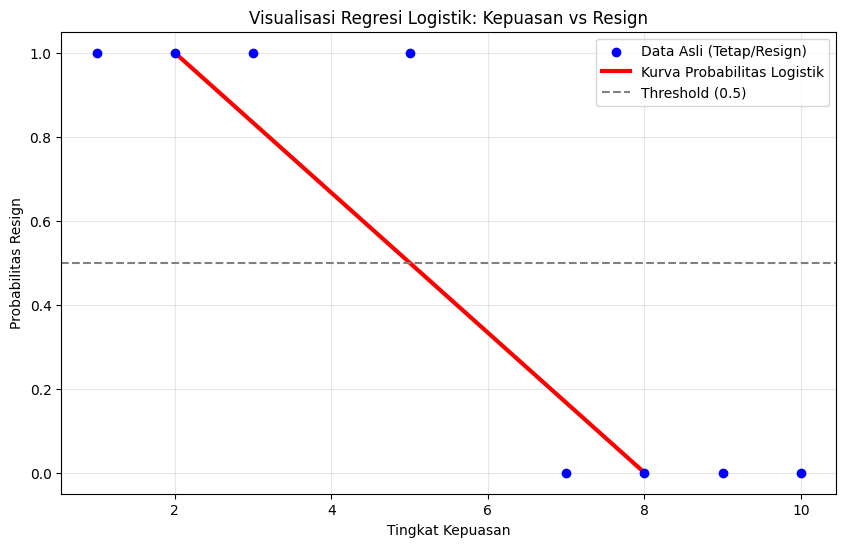

In [29]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Data Asli (Tetap/Resign)', zorder=5)
plt.plot(X_test, y_pred, color='red', linewidth=3, label='Kurva Probabilitas Logistik')
plt.axhline(y=0.5, color='gray', linestyle='--', label='Threshold (0.5)')
plt.title('Visualisasi Regresi Logistik: Kepuasan vs Resign')
plt.xlabel('Tingkat Kepuasan')
plt.ylabel('Probabilitas Resign')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

1. **Titik Biru** (Data Asli):
Kamu akan melihat titik-titik berada di angka 1 (untuk kepuasan rendah) dan di angka 0 (untuk kepuasan tinggi). Ini menunjukkan kondisi riil karyawan saat ini.

2. **Kurva Merah** (Sigmoid):
Inilah "otak" dari Regresi Logistik. Kurva ini tidak lurus seperti Regresi Linear, melainkan melengkung halus.
   * Saat kepuasan rendah, kurva berada di atas (mendekati 1).
   * Saat kepuasan tinggi, kurva turun ke bawah (mendekati 0).

3. **Garis Putus-putus** (Threshold 0.5):
Ini adalah garis penentu.
   * Jika kurva merah berada di atas garis ini, AI akan memprediksi "Ya, Resign".
   * Jika kurva merah berada di bawah garis ini, AI akan memprediksi "Tidak, Tetap".

**Analisis Akhir**

**1. Klasifikasi vs Regresi**:
Regresi Linear (sebelumnya) digunakan untuk memprediksi angka kontinu (seperti harga rumah), sedangkan Regresi Logistik digunakan untuk memprediksi kelas/label (Resign vs Tetap).

**2. Akurasi**:
Dengan data yang terbagi jelas (1-5 resign, 7-10 tetap), model ini akan memiliki akurasi yang sangat tinggi. Tantangan sebenarnya muncul jika ada data "noise", misalnya ada orang yang kepuasannya 9 tapi tetap resign.

**3. Confusion Matrix**:
Ini adalah bagian terpenting untuk analisis. Dalam kasus resign, perusahaan lebih takut salah tebak orang yang "dikira tetap tapi ternyata resign" (False Negative). Tabel ini membantu perusahaan melihat seberapa sering AI salah tebak.

**4. Kegunaan**:
Model ini adalah dasar dari Churn Prediction yang digunakan oleh perusahaan telekomunikasi atau bank untuk memprediksi pelanggan mana yang akan berhenti berlangganan.